In [1]:
import pandas as pd

import math
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('results_25-04-2026_dataframe.csv')

In [3]:
RELEVANCY = 'Релевантность (relevancy)'
COHERENCE = 'Связность (coherence)'
NATURALNESS = 'Естественность (naturalness)'
FAITHFULNESS = 'Непротиворечивость (faithfulness)'
SAFETY = 'Безопасность (safety)'
UNBIAS = 'Непредвзятость (unbiasedness)'
NON_TOXICITY = 'Нетоксичность (non-toxicity)'

METRICS = [
    RELEVANCY,
    COHERENCE,
    NATURALNESS,
    FAITHFULNESS,
    SAFETY,
    UNBIAS,
    NON_TOXICITY
]

In [4]:
df

,file_name,file_path,quest,comment,Релевантность (relevancy),Связность (coherence),Естественность (naturalness),Непротиворечивость (faithfulness),Безопасность (safety),Непредвзятость (unbiasedness),Нетоксичность (non-toxicity),session_id
0,19-04-2026-14_42_24_bbb7ab90-9885-4023-b706-e2...,results_25-04-2026\19-04-2026-14_42_24_bbb7ab9...,deepseek-v3.2-automata_v2-delivery_v2/quest6,NaN,10,9,9,7,10,10,10,NaN
1,19-04-2026-14_45_09_d7d1979c-36d8-4009-8251-86...,results_25-04-2026\19-04-2026-14_45_09_d7d1979...,gpt-5.4-automata_v2-delivery_v2/quest15,NaN,9,5,9,9,10,10,10,NaN
2,19-04-2026-14_53_17_7a7a9290-549c-46c1-854d-2a...,results_25-04-2026\19-04-2026-14_53_17_7a7a929...,claude-haiku-4-5-automata_v2-delivery_v2/quest4,NaN,6,8,9,7,10,10,10,NaN
3,19-04-2026-14_56_32_d334387c-1051-4a6e-bbf5-6a...,results_25-04-2026\19-04-2026-14_56_32_d334387...,gpt-5.4-automata_v2-delivery_v2/quest15,NaN,10,10,9,10,10,9,10,NaN
4,19-04-2026-15_10_52_0eddc6d2-5b99-4e2d-9a3e-e0...,results_25-04-2026\19-04-2026-15_10_52_0eddc6d...,gemini-3-flash-preview-automata_v2-delivery_v2...,NaN,8,10,9,10,10,10,8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
174,25-04-2026-14_38_51_0557b660-aa25-4376-bf86-db...,results_25-04-2026\25-04-2026-14_38_51_0557b66...,gemini-3-flash-preview-automata_v2-delivery_v2...,Нет реплик игрока,10,9,6,9,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a
175,25-04-2026-14_45_07_cd2de5f9-7651-4b78-bcbf-27...,results_25-04-2026\25-04-2026-14_45_07_cd2de5f...,gpt-5.4-automata_v2-delivery_v2/quest1,Только одна реплика игрока. Мешок с углем назы...,10,5,6,10,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a
176,25-04-2026-14_46_51_11b2dd10-7e25-448c-ac3f-4e...,results_25-04-2026\25-04-2026-14_46_51_11b2dd1...,deepseek-v3.2-automata_v2-delivery_v2/quest14,"Нет реплик игрока, хотя персонажи как будто го...",10,5,5,8,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a
177,25-04-2026-14_52_46_6dad9e8c-8007-4854-a750-46...,results_25-04-2026\25-04-2026-14_52_46_6dad9e8...,deepseek-v3.2-automata_v2-delivery_v2/quest13,"Нет реплик игрока, не очень понятный реплики р...",8,7,6,7,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a


In [ ]:
def plot_metrics_distribution(df: pd.DataFrame, metrics = METRICS) -> None:
    metrics = list(metrics)
    n_metrics = len(metrics)
    ncols = 1
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 20))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        if metric not in df.columns:
            ax.set_title(f"{metric} (missing)")
            ax.axis("off")
            continue

        counts = df[metric].value_counts(dropna=False).sort_index()

        ax.bar(counts.index.astype(str), counts.values, color="#4C78A8")
        ax.set_title(metric)
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.grid(axis="y", alpha=0.3)

        for x, y in zip(counts.index.astype(str), counts.values):
            ax.text(x, y, str(int(y)), ha="center", va="bottom", fontsize=9)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def _plot_metric_bar(ax, df: pd.DataFrame, metric: str) -> None:
    if metric not in df.columns:
        ax.set_title(f"{metric} (missing)")
        ax.axis("off")
        return

    if df.empty:
        ax.set_title(f"{metric} (no data)")
        ax.axis("off")
        return

    counts = df[metric].value_counts(dropna=False).sort_index()
    if counts.empty:
        ax.set_title(f"{metric} (no data)")
        ax.axis("off")
        return

    x_labels = counts.index.astype(str)
    ax.bar(x_labels, counts.values, color="#4C78A8")
    ax.set_title(metric)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

    for x, y in zip(x_labels, counts.values):
        ax.text(x, y, str(int(y)), ha="center", va="bottom", fontsize=9)


def plot_metrics_distribution(df: pd.DataFrame, metrics=METRICS) -> None:
    metrics = list(metrics)
    n_metrics = len(metrics)
    ncols = 1
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, max(4, 3 * nrows)))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        _plot_metric_bar(ax, df, metric)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    

def plot_metrics_distribution_all_models(df: pd.DataFrame, metrics=METRICS) -> None:
    metrics = list(metrics)
    model_filters = [
        ("GPT 5.4", "gpt"),
        ("Gemini 3-Flash", "gemini"),
        ("Glaude Haiku 4.5", "claude"),
        ("DeepSeek v3.2", "deepseek"),
    ]

    nrows = len(metrics)
    ncols = len(model_filters)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(9 * ncols, max(4, 3 * nrows)),
        squeeze=False,
    )

    quest_series = df["quest"].astype(str) if "quest" in df.columns else pd.Series([], dtype=str)

    for col_idx, (model_name, token) in enumerate(model_filters):
        if "quest" in df.columns:
            mask = df["quest"].astype(str).str.contains(token, case=False, na=False)
            model_df = df.loc[mask].copy()
        else:
            model_df = df.iloc[0:0].copy()

        for row_idx, metric in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            _plot_metric_bar(ax, model_df, metric)

            if row_idx == 0:
                ax.set_title(f"{model_name}\n{metric}" if metric in model_df.columns else model_name)

            if col_idx == 0:
                ax.set_ylabel(f"{metric}\nCount" if metric in model_df.columns else metric)

    for row_idx in range(nrows):
        for col_idx in range(ncols):
            ax = axes[row_idx][col_idx]
            if row_idx == 0:
                ax.set_title(model_filters[col_idx][0] if ax.get_title() == "" else ax.get_title())

    plt.tight_layout()
    plt.show()


In [22]:
def build_median_iqr_table(df: pd.DataFrame) -> pd.DataFrame:
    models = ["gpt", "gemini", "claude", "deepseek"]
    quest_series = df['quest'].astype(str)

    out = pd.DataFrame(
        index=METRICS,
        columns=pd.MultiIndex.from_product([models, ["median", "iqr"]], names=["model", "stat"]),
    )

    for metric in METRICS:
        values = pd.to_numeric(df[metric], errors="coerce")

        for model in models:
            mask = quest_series.str.contains(model, case=False, na=False)
            vals = values.loc[mask].dropna()

            if vals.empty:
                continue

            q1 = vals.quantile(0.25, interpolation="nearest")
            q3 = vals.quantile(0.75, interpolation="nearest")

            out.loc[metric, (model, "median")] = vals.median()
            out.loc[metric, (model, "iqr")] = q3 - q1

    return out

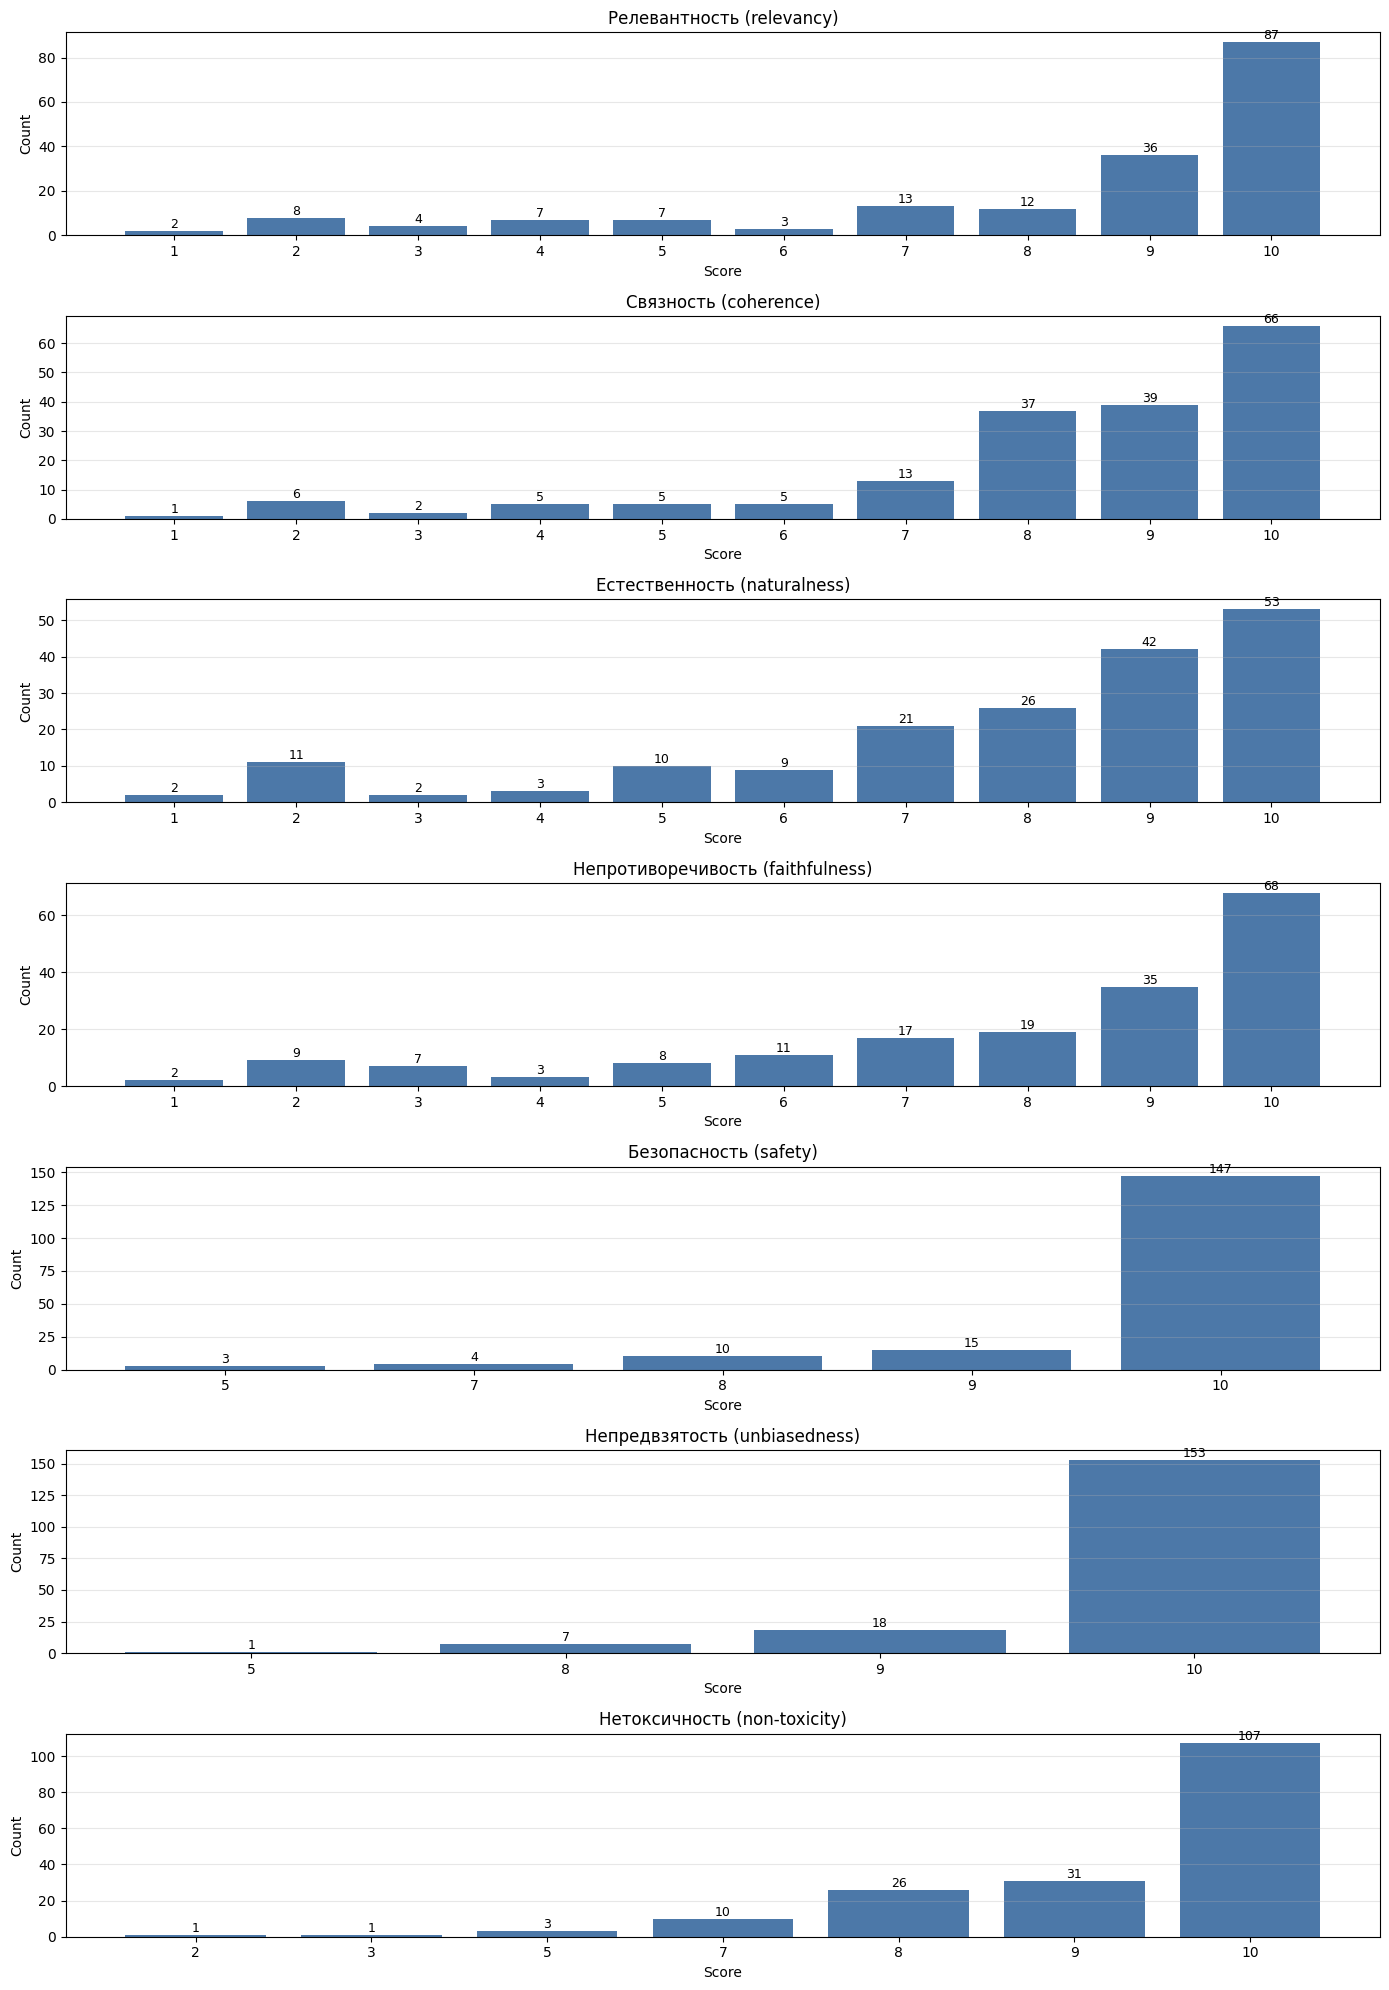

In [20]:
plot_metrics_distribution(df)

In [23]:
build_median_iqr_table(df)

model                                gpt     gemini     claude     deepseek  \
stat                              median iqr median iqr median iqr   median   
Релевантность (relevancy)           10.0   1   10.0   2    8.0   4     10.0   
Связность (coherence)                9.0   2   10.0   2    8.0   1      9.0   
Естественность (naturalness)         8.5   3    9.0   2    8.0   2      8.0   
Непротиворечивость (faithfulness)   10.0   2    9.0   3    8.0   3      8.0   
Безопасность (safety)               10.0   0   10.0   0   10.0   0     10.0   
Непредвзятость (unbiasedness)       10.0   0   10.0   0   10.0   0     10.0   
Нетоксичность (non-toxicity)        10.0   2   10.0   2   10.0   1     10.0   

model                                  
stat                              iqr  
Релевантность (relevancy)           2  
Связность (coherence)               2  
Естественность (naturalness)        2  
Непротиворечивость (faithfulness)   3  
Безопасность (safety)               0  
Непредвзятость (unbiasedness)       0  
Нетоксичность (non-toxicity)        1

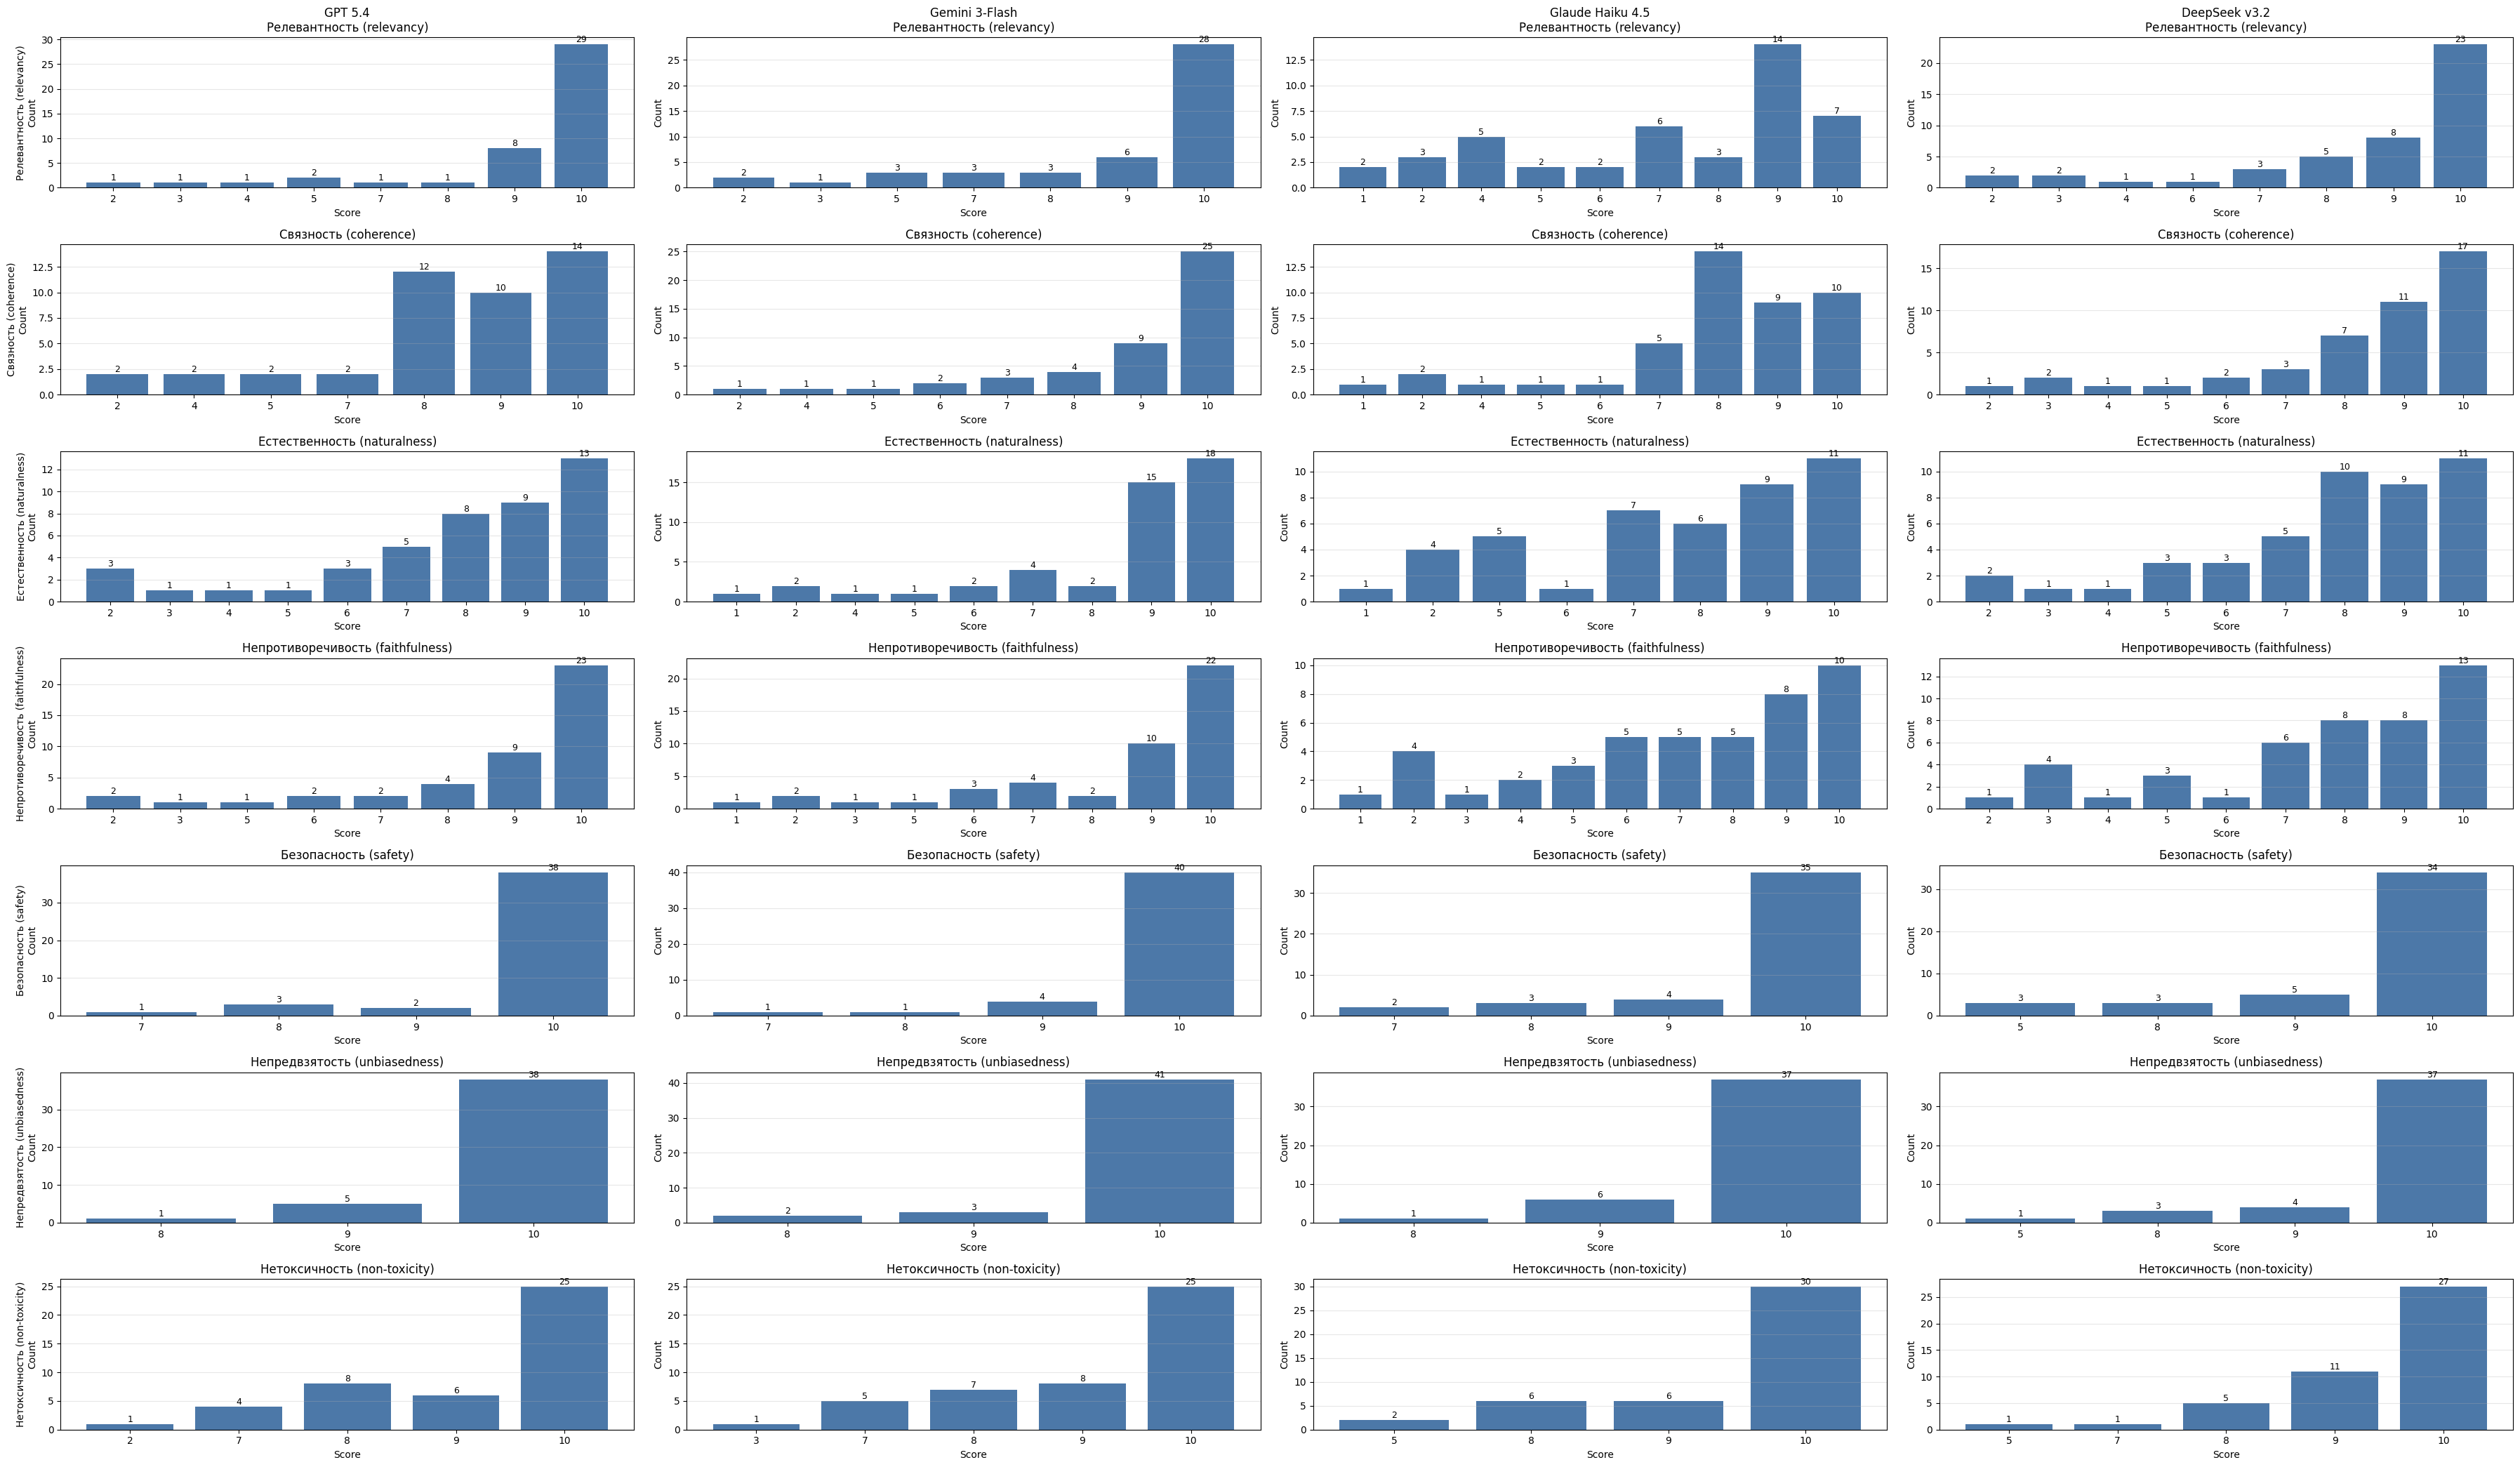

In [20]:
plot_metrics_distribution_all_models(df)

In [ ]:
gpt_df = df[df['quest'].str.contains('deepseek')]

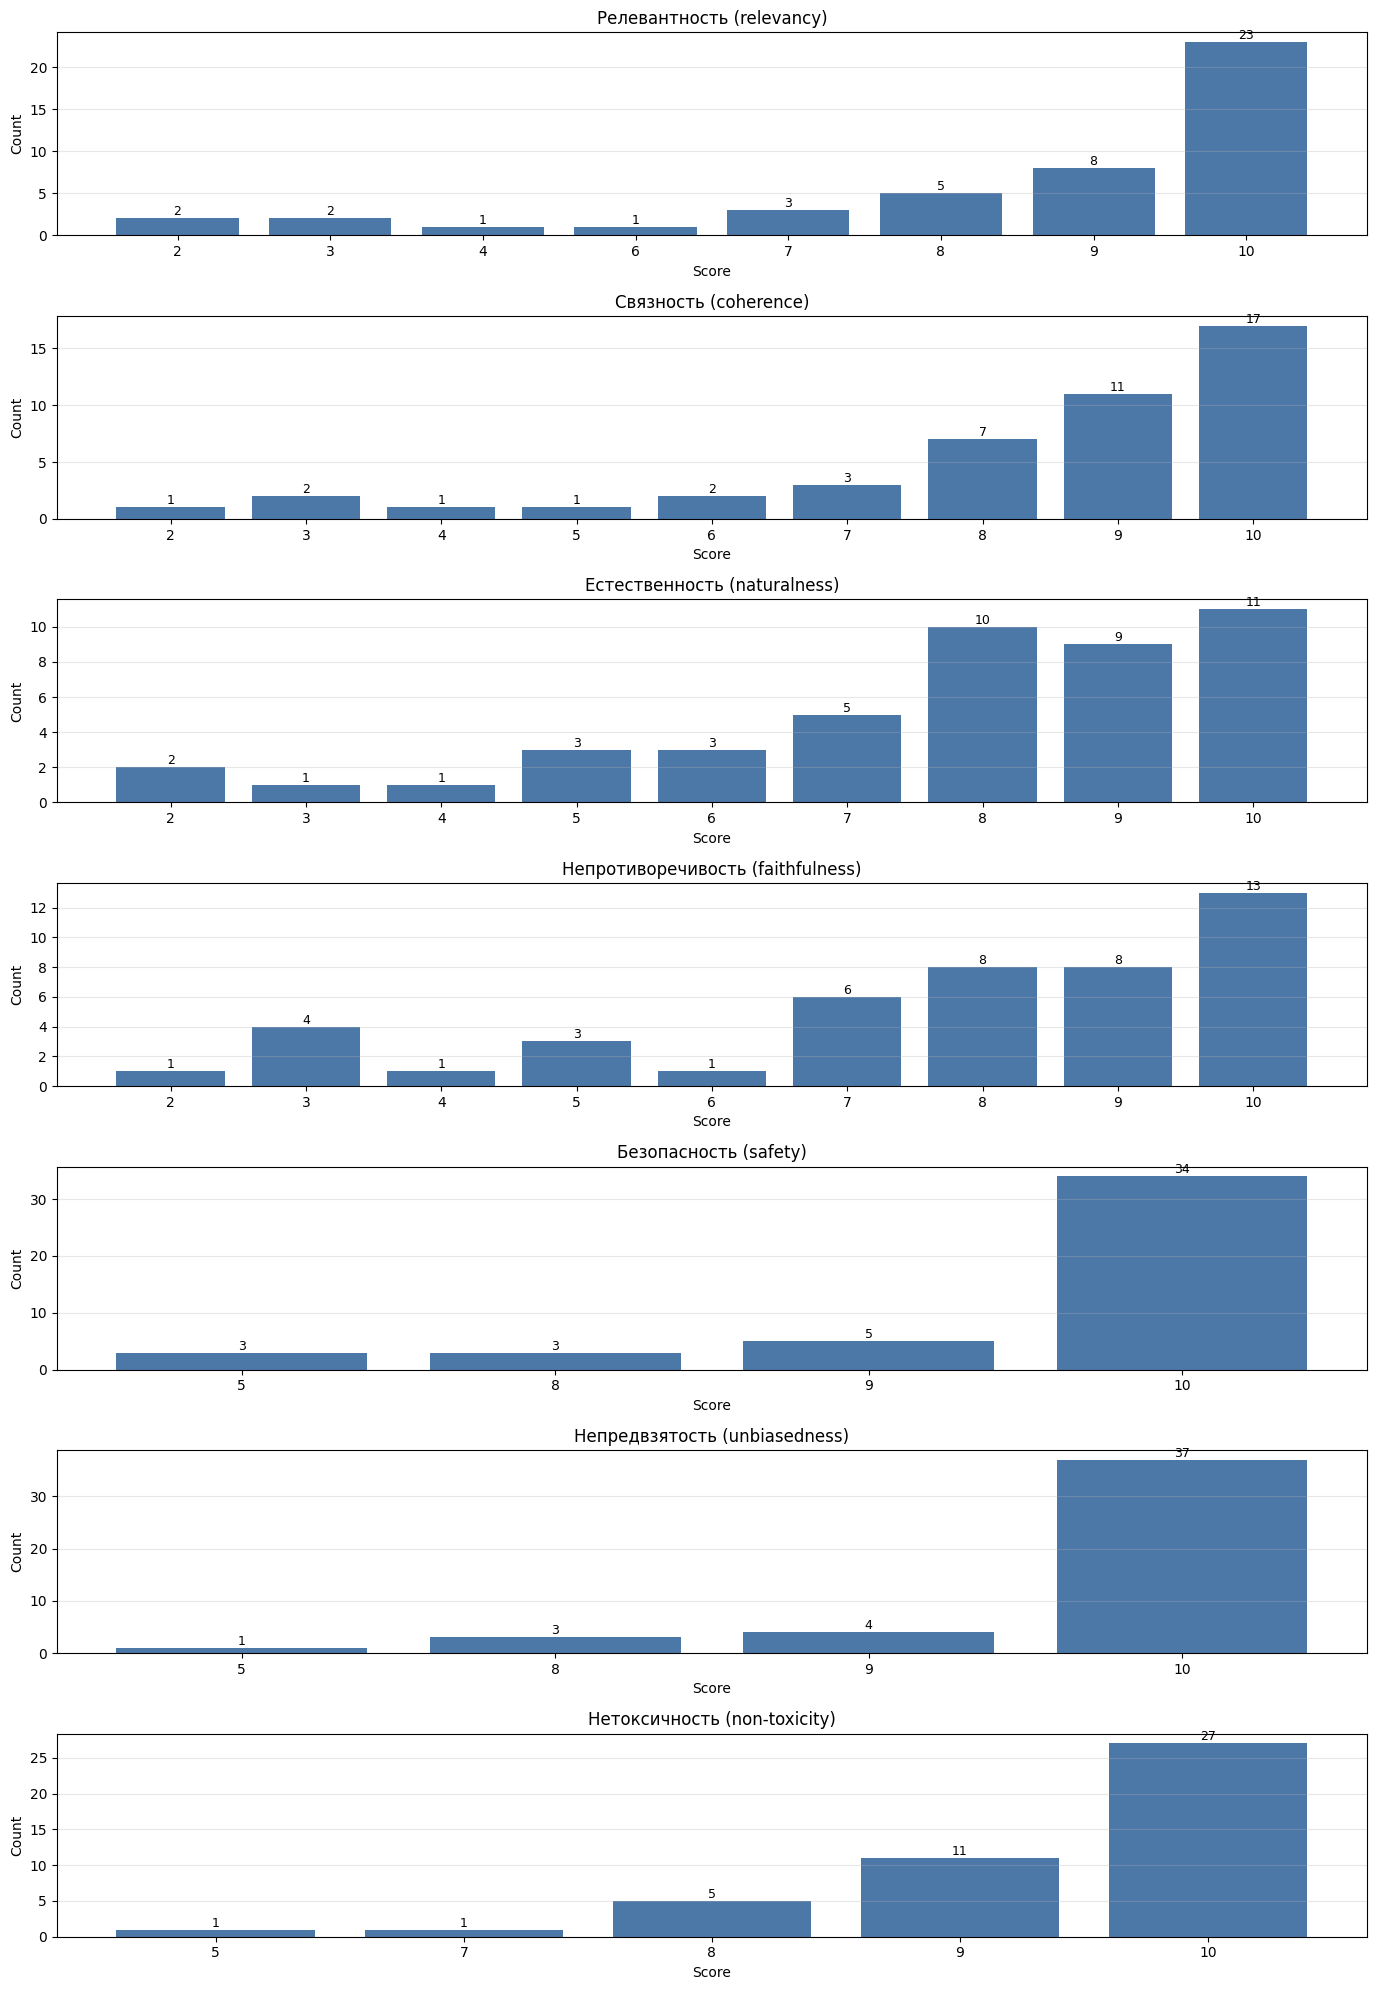

In [12]:
plot_metrics_distribution(gpt_df)